<a href="https://colab.research.google.com/github/shailooz/EDA_DV/blob/main/2_Wrangling/Wrangling_Pandas_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import the necessary libraries

In [1]:
import pandas as pd

Mount the google drive and set your path to the parent directory where you save your dataset

Reading the .csv file

In [2]:
df=pd.read_csv("Salaries.csv")
print(df)

         rank discipline  phd  service     sex  salary
0        Prof          B   56       49    Male  186960
1        Prof          A   12        6    Male   93000
2        Prof          A   23       20    Male  110515
3        Prof          A   40       31    Male  131205
4        Prof          B   20       18    Male  104800
..        ...        ...  ...      ...     ...     ...
73       Prof          B   18       10  Female  105450
74  AssocProf          B   19        6  Female  104542
75       Prof          B   17       17  Female  124312
76       Prof          A   28       14  Female  109954
77       Prof          A   23       15  Female  109646

[78 rows x 6 columns]


Exploring the dataframes

In [3]:
df.head()

,rank,discipline,phd,service,sex,salary
0,Prof,B,56,49,Male,186960
1,Prof,A,12,6,Male,93000
2,Prof,A,23,20,Male,110515
3,Prof,A,40,31,Male,131205
4,Prof,B,20,18,Male,104800


In [4]:
df.tail()

,rank,discipline,phd,service,sex,salary
73,Prof,B,18,10,Female,105450
74,AssocProf,B,19,6,Female,104542
75,Prof,B,17,17,Female,124312
76,Prof,A,28,14,Female,109954
77,Prof,A,23,15,Female,109646


In [5]:
df.columns
print(df[['phd','rank']])

    phd       rank
0    56       Prof
1    12       Prof
2    23       Prof
3    40       Prof
4    20       Prof
..  ...        ...
73   18       Prof
74   19  AssocProf
75   17       Prof
76   28       Prof
77   23       Prof

[78 rows x 2 columns]


In [6]:
print(df['rank'].dtype)

object


Data Frames attributes


In [7]:
df.dtypes

,0
rank,object
discipline,object
phd,int64
service,int64
sex,object
salary,int64


In [8]:
df.shape

(78, 6)

Data Frames methods

In [9]:
df[['phd']].mean()

,0
phd,19.705128


In [10]:
# print(df.mean())

Selecting a column in a Data Frame

In [11]:
print(df['sex'])
print(df.sex)

0       Male
1       Male
2       Male
3       Male
4       Male
       ...  
73    Female
74    Female
75    Female
76    Female
77    Female
Name: sex, Length: 78, dtype: object
0       Male
1       Male
2       Male
3       Male
4       Male
       ...  
73    Female
74    Female
75    Female
76    Female
77    Female
Name: sex, Length: 78, dtype: object


In [12]:
df['salary'].mean()


np.float64(108023.78205128205)

Data Frames groupby method

In [14]:
#Group data using rank
df_rank = df.groupby(['rank'])
#Calculate mean value for each numeric column per each group
df_rank.mean(numeric_only=True)

,phd,service,salary
rank,,,
AssocProf,15.076923,11.307692,91786.230769
AsstProf,5.052632,2.210526,81362.789474
Prof,27.065217,21.413043,123624.804348


In [15]:
#Calculate mean salary for each professor rank:
df.groupby('rank')[['salary']].mean()

,salary
rank,
AssocProf,91786.230769
AsstProf,81362.789474
Prof,123624.804348


In [16]:
#pass sort=False for potential speedup:
df_rank=df.groupby(['rank'],sort=False)[['salary']]
print(df_rank.mean())

                  salary
rank                    
Prof       123624.804348
AssocProf   91786.230769
AsstProf    81362.789474


Data Frame: filtering

In [17]:
#Calculate mean salary for each professor rank:
df_sub = df[ df['salary'] > 120000 ]

In [18]:
#Select only those rows that contain female professors:
df_f = df[ df['sex'] == 'Female' ]

Data Frames: Slicing

In [19]:
#Select column salary:
df['salary']

,salary
0,186960
1,93000
2,110515
3,131205
4,104800
...,...
73,105450
74,104542
75,124312
76,109954


In [20]:
#Select column salary:
df[['rank','salary']]

,rank,salary
0,Prof,186960
1,Prof,93000
2,Prof,110515
3,Prof,131205
4,Prof,104800
...,...,...
73,Prof,105450
74,AssocProf,104542
75,Prof,124312
76,Prof,109954


In [21]:
#Select rows by their position-[starting_row:ending_row]
df[10:20]

,rank,discipline,phd,service,sex,salary
10,Prof,B,39,33,Male,128250
11,Prof,B,23,23,Male,134778
12,AsstProf,B,1,0,Male,88000
13,Prof,B,35,33,Male,162200
14,Prof,B,25,19,Male,153750
15,Prof,B,17,3,Male,150480
16,AsstProf,B,8,3,Male,75044
17,AsstProf,B,4,0,Male,92000
18,Prof,A,19,7,Male,107300
19,Prof,A,29,27,Male,150500


In [22]:
#Select rows by their labels:
df_sub.loc[10:20,['rank','sex','salary']]

,rank,sex,salary
10,Prof,Male,128250
11,Prof,Male,134778
13,Prof,Male,162200
14,Prof,Male,153750
15,Prof,Male,150480
19,Prof,Male,150500


In [23]:
#Select rows by their labels:
df_sub.loc[10:20,['rank','sex','salary']]

,rank,sex,salary
10,Prof,Male,128250
11,Prof,Male,134778
13,Prof,Male,162200
14,Prof,Male,153750
15,Prof,Male,150480
19,Prof,Male,150500


In [24]:
#Select rows by their labels:
df_sub.iloc[10:20,[0, 3, 4, 5]]

,rank,service,sex,salary
26,Prof,19,Male,148750
27,Prof,43,Male,155865
29,Prof,20,Male,123683
31,Prof,21,Male,155750
35,Prof,23,Male,126933
36,Prof,45,Male,146856
39,Prof,18,Female,129000
40,Prof,36,Female,137000
44,Prof,19,Female,151768
45,Prof,25,Female,140096


In [25]:
df.iloc[0]  # First row of a data frame
# df.iloc[i]  #(i+1)th row
# df.iloc[-1] # Last row

,0
rank,Prof
discipline,B
phd,56
service,49
sex,Male
salary,186960


In [26]:
df.iloc[:, 0]  # First column
# df.iloc[:, -1] # Last column

,rank
0,Prof
1,Prof
2,Prof
3,Prof
4,Prof
...,...
73,Prof
74,AssocProf
75,Prof
76,Prof


In [27]:
df.iloc[0:7]       #First 7 rows
# df.iloc[:, 0:2]    #First 2 columns
# df.iloc[1:3, 0:2]  #Second through third rows and first 2 columns
# df.iloc[[0,5], [1,3]]  #1st and 6th rows and 2nd and 4th columns

,rank,discipline,phd,service,sex,salary
0,Prof,B,56,49,Male,186960
1,Prof,A,12,6,Male,93000
2,Prof,A,23,20,Male,110515
3,Prof,A,40,31,Male,131205
4,Prof,B,20,18,Male,104800
5,Prof,A,20,20,Male,122400
6,AssocProf,A,20,17,Male,81285


In [28]:
# Create a new data frame from the original sorted by the column Salary
df_sorted = df.sort_values( by ='service')
df_sorted.head()


,rank,discipline,phd,service,sex,salary
12,AsstProf,B,1,0,Male,88000
17,AsstProf,B,4,0,Male,92000
23,AsstProf,A,2,0,Male,85000
43,AsstProf,B,5,0,Female,77000
55,AsstProf,A,2,0,Female,72500


In [29]:
df_sorted = df.sort_values( by ='service',ascending=False)
df_sorted.head(20)

,rank,discipline,phd,service,sex,salary
9,Prof,A,51,51,Male,57800
0,Prof,B,56,49,Male,186960
36,Prof,B,45,45,Male,146856
27,Prof,A,45,43,Male,155865
40,Prof,A,39,36,Female,137000
10,Prof,B,39,33,Male,128250
13,Prof,B,35,33,Male,162200
25,Prof,B,35,31,Male,99418
3,Prof,A,40,31,Male,131205
21,Prof,A,33,30,Male,103106


In [30]:
#sort the data using 2 or more columns:
df_sorted = df.sort_values( by =['service', 'salary'], ascending = [True, False])
df_sorted.head(10)

,rank,discipline,phd,service,sex,salary
52,Prof,A,12,0,Female,105000
17,AsstProf,B,4,0,Male,92000
12,AsstProf,B,1,0,Male,88000
23,AsstProf,A,2,0,Male,85000
43,AsstProf,B,5,0,Female,77000
55,AsstProf,A,2,0,Female,72500
57,AsstProf,A,3,1,Female,72500
28,AsstProf,B,7,2,Male,91300
42,AsstProf,B,4,2,Female,80225
68,AsstProf,A,4,2,Female,77500


In [31]:
# Drop the 'Math' column

df_sorted.drop(columns = 'phd')
df_sorted.head(10)

,rank,discipline,phd,service,sex,salary
52,Prof,A,12,0,Female,105000
17,AsstProf,B,4,0,Male,92000
12,AsstProf,B,1,0,Male,88000
23,AsstProf,A,2,0,Male,85000
43,AsstProf,B,5,0,Female,77000
55,AsstProf,A,2,0,Female,72500
57,AsstProf,A,3,1,Female,72500
28,AsstProf,B,7,2,Male,91300
42,AsstProf,B,4,2,Female,80225
68,AsstProf,A,4,2,Female,77500


In [32]:
# Describe function on numerical variable

df_sorted['salary'].describe()

,salary
count,78.000000
mean,108023.782051
std,28293.661022
min,57800.000000
25%,88612.500000
50%,104671.000000
75%,126774.750000
max,186960.000000


In [33]:
# What is the median salary?

df_sorted['salary'].median()


104671.0

In [34]:
# Encode male as 1 and female as 0
df_sorted['Encoded Sex'] = df_sorted['sex'].map({'Male':1, 'Female':0})

In [35]:
# Check for null values

df_sorted.isnull().sum()

,0
rank,0
discipline,0
phd,0
service,0
sex,0
salary,0
Encoded Sex,0


In [36]:
df['sex'].value_counts()

,count
sex,
Male,39
Female,39


Missing Values

In [37]:
# Read a dataset with missing values
flights = pd.read_csv("flights.csv")

In [38]:
# Select the rows that have at least one missing value
flights[flights.isnull().any(axis=1)].head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
471,2013,1,1,1525.0,1530,-5.0,1934.0,1805,NaN,MQ,4525,N719MQ,LGA,XNA,NaN,1147,15,30,1/1/2013 15:00
477,2013,1,1,1528.0,1459,29.0,2002.0,1647,NaN,EV,3806,N17108,EWR,STL,NaN,872,14,59,1/1/2013 14:00
615,2013,1,1,1740.0,1745,-5.0,2158.0,2020,NaN,MQ,4413,N739MQ,LGA,XNA,NaN,1147,17,45,1/1/2013 17:00
643,2013,1,1,1807.0,1738,29.0,2251.0,2103,NaN,UA,1228,N31412,EWR,SAN,NaN,2425,17,38,1/1/2013 17:00
725,2013,1,1,1939.0,1840,59.0,29.0,2151,NaN,9E,3325,N905XJ,JFK,DFW,NaN,1391,18,40,1/1/2013 18:00


In [39]:
flights[['dep_delay','arr_delay']].agg(['min','mean','max'])

,dep_delay,arr_delay
min,-43.00000,-86.000000
mean,12.63907,6.895377
max,1301.00000,1272.000000


In [40]:
import matplotlib.pyplot as plt

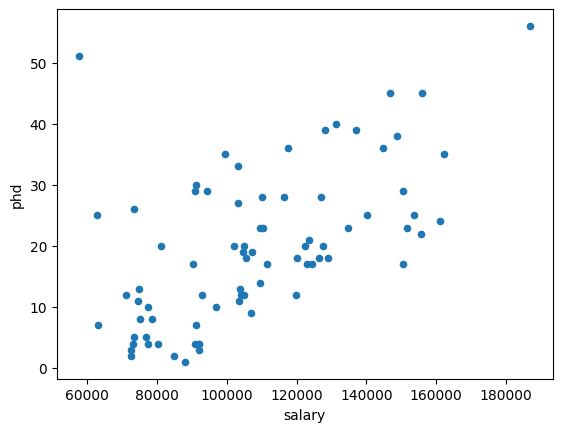

In [41]:
df.plot(kind = 'scatter', x = 'salary', y = 'phd')
plt.show()

### Visualizing Departure and Arrival Delays (using Pandas plotting)

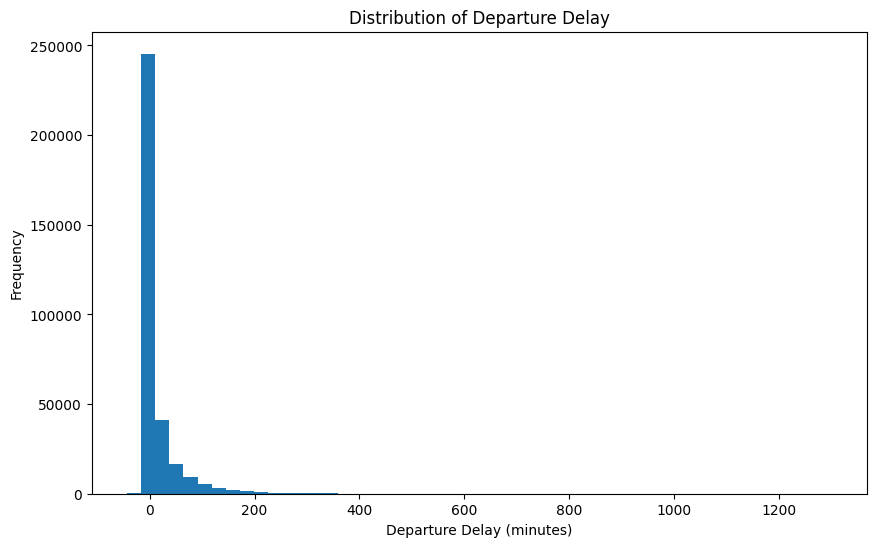

In [43]:
# Distribution of Departure Delay
flights['dep_delay'].dropna().plot.hist(bins=50, title='Distribution of Departure Delay', xlabel='Departure Delay (minutes)', ylabel='Frequency', figsize=(10, 6))
plt.show()

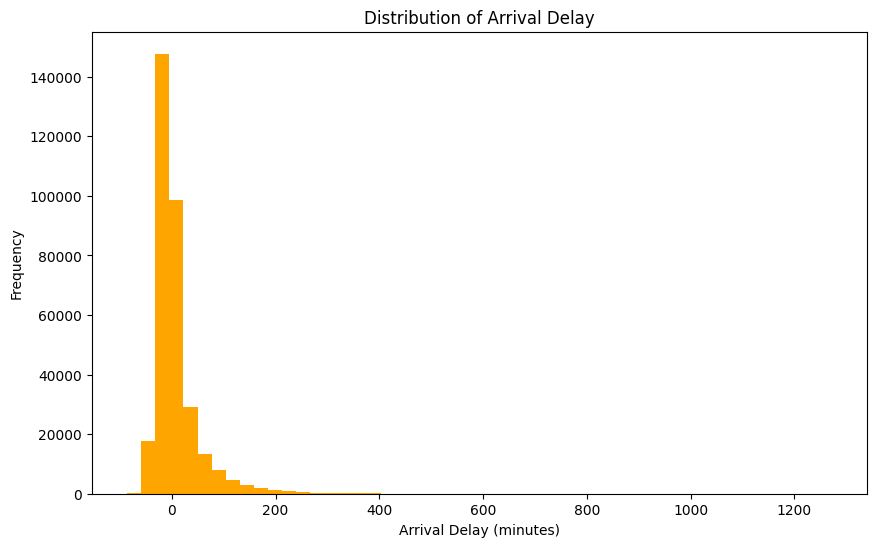

In [44]:
# Distribution of Arrival Delay
flights['arr_delay'].dropna().plot.hist(bins=50, title='Distribution of Arrival Delay', xlabel='Arrival Delay (minutes)', ylabel='Frequency', figsize=(10, 6), color='orange')
plt.show()

### Relationship between Departure and Arrival Delays (using Pandas plotting)

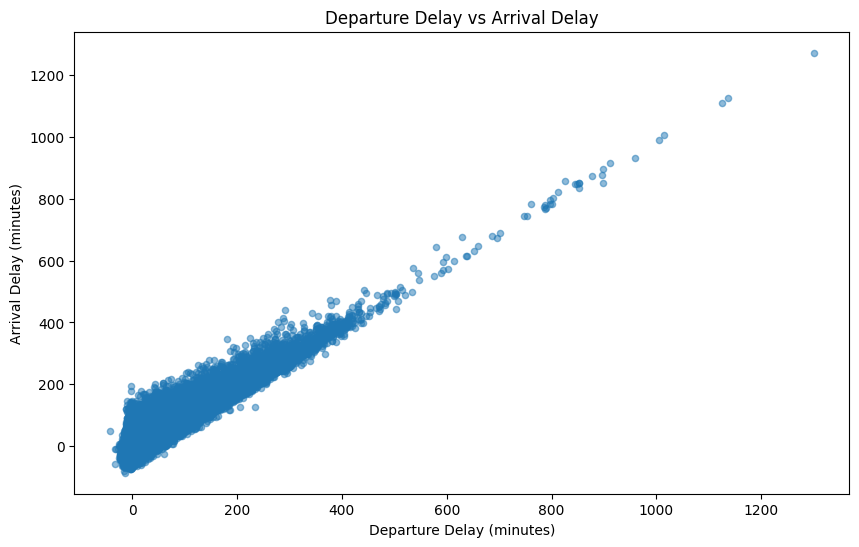

In [45]:
# Scatter plot of Departure Delay vs Arrival Delay
flights.plot.scatter(x='dep_delay', y='arr_delay', alpha=0.5, title='Departure Delay vs Arrival Delay', xlabel='Departure Delay (minutes)', ylabel='Arrival Delay (minutes)', figsize=(10, 6))
plt.show()

### Average Delay per Carrier (using Pandas plotting)

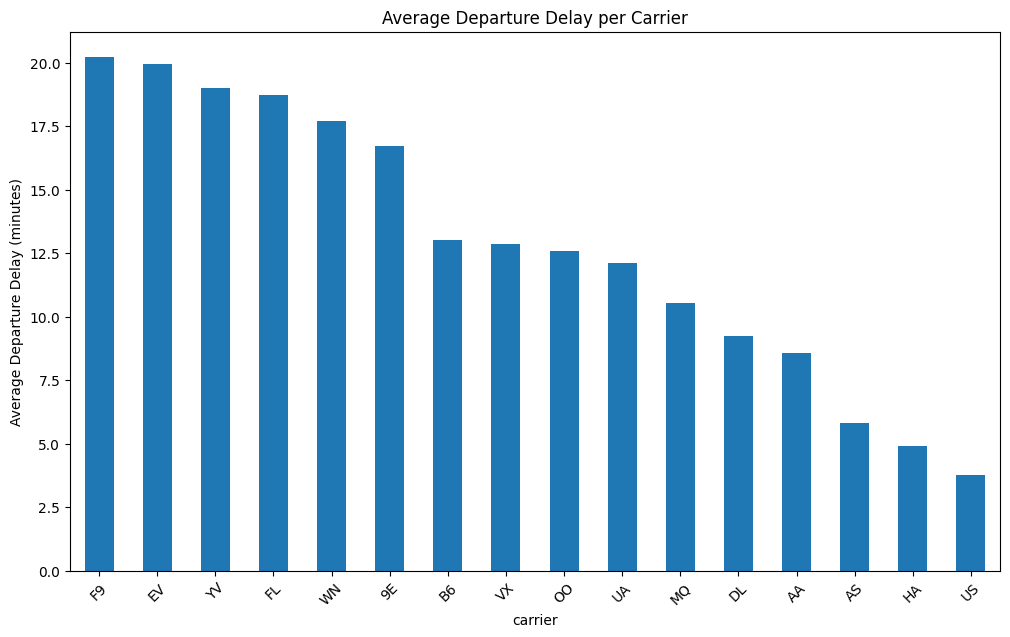

In [46]:
# Calculate average departure delay per carrier and plot
avg_dep_delay_per_carrier = flights.groupby('carrier')['dep_delay'].mean().sort_values(ascending=False)
avg_dep_delay_per_carrier.plot.bar(figsize=(12, 7), title='Average Departure Delay per Carrier', ylabel='Average Departure Delay (minutes)', rot=45)
plt.show()

### Relationship between Flight Distance and Air Time (using Pandas plotting)

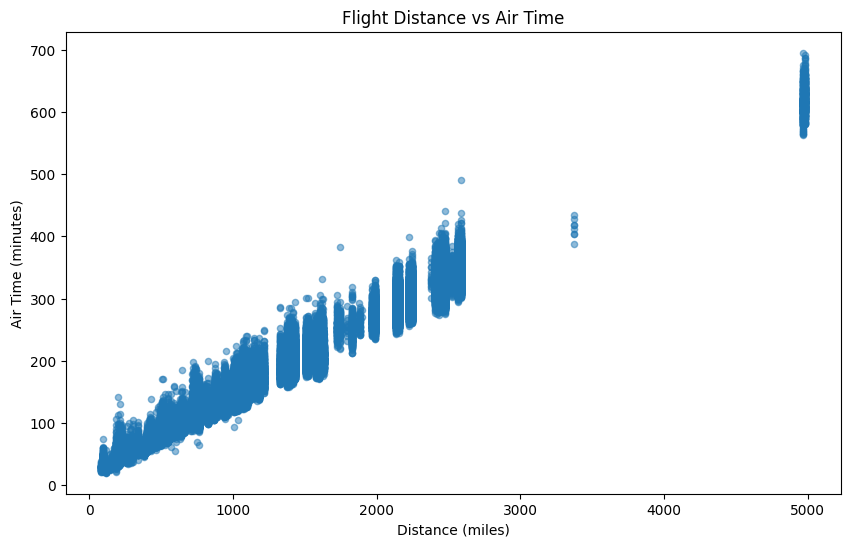

In [47]:
# Scatter plot of Distance vs Air Time
flights.plot.scatter(x='distance', y='air_time', alpha=0.5, title='Flight Distance vs Air Time', xlabel='Distance (miles)', ylabel='Air Time (minutes)', figsize=(10, 6))
plt.show()

### Distribution of Flight Distances (using Pandas plotting)

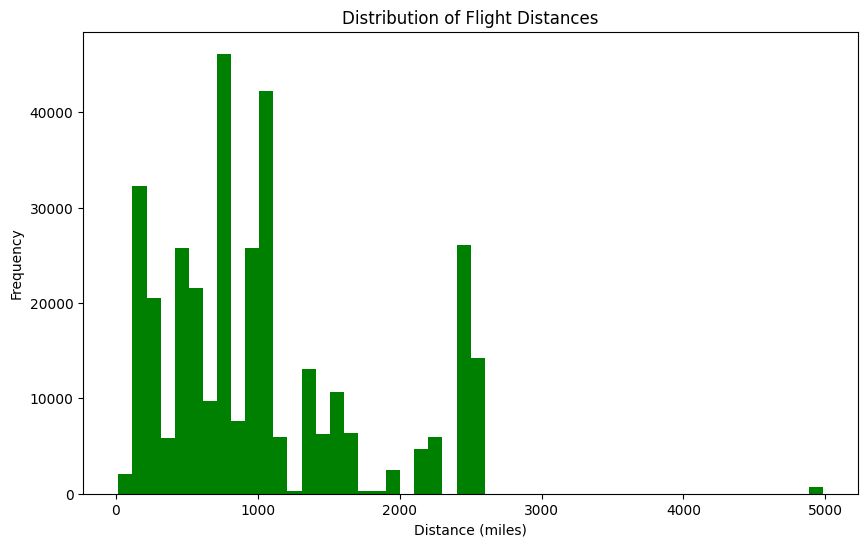

In [48]:
# Histogram of Flight Distances
flights['distance'].plot.hist(bins=50, title='Distribution of Flight Distances', xlabel='Distance (miles)', ylabel='Frequency', figsize=(10, 6), color='green')
plt.show()